##### In this we are creating second sub graph into the first main graph and there state witll be same

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
class ParentState(TypedDict):

      question : str
      answer_eng : str
      answer_hin : str

In [4]:
subgraph_llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.7)
parent_llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.7)

In [5]:
def translate_text(state : ParentState):

      prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state['answer_eng']}
"""
      result = subgraph_llm.invoke(prompt).content

      return {"answer_hin" : result}

In [6]:
subgraphbuild = StateGraph(ParentState)

subgraphbuild.add_node("translate_text", translate_text)

subgraphbuild.add_edge(START, "translate_text")
subgraphbuild.add_edge("translate_text", END)

subgraph = subgraphbuild.compile()

In [7]:
def generate(state : ParentState):

      prompt = f"""
You are an helpful asistant.
Answer the question with clearity and keep it natural.

Question:
{state['question']}
"""
      result = parent_llm.invoke(prompt).content

      return {"answer_eng" : result}

In [8]:
parentbuild = StateGraph(ParentState)

parentbuild.add_node("generate", generate)
parentbuild.add_node("translate", subgraph)

parentbuild.add_edge(START, "generate")
parentbuild.add_edge("generate", "translate")
parentbuild.add_edge("translate", END)

parentgraph = parentbuild.compile()

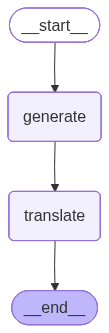

In [9]:
parentgraph

In [10]:
answer = parentgraph.invoke({'question' : 'What is quantum Physics and also tell me about the god particle'})
answer

{'question': 'What is quantum Physics and also tell me about the god particle',
 'answer_eng': 'To put it simply, quantum physics is the study of the universe at its smallest possible level—the level of atoms and the subatomic particles inside them.\n\nHere is a breakdown of both topics in a way that’s easy to digest.\n\n---\n\n### 1. What is Quantum Physics?\n\nIn our everyday world, things follow "classical" rules (Newton’s laws). If you throw a ball, you know exactly where it’s going. But in the quantum world, those rules break down and things get very "weird."\n\nThink of it like this:\n*   **Probability, not Certainty:** In the macro world, an object is in one place at one time. In the quantum world, a particle doesn\'t have a single fixed location; it exists in a "cloud" of possibilities until someone looks at it.\n*   **Wave-Particle Duality:** Tiny things, like electrons or light, can act like solid little marbles (particles) and ripples in a pond (waves) at the same time.\n*  